<a href="https://colab.research.google.com/github/dinda-dwi-lestari/Pengantar-Proses-Stokastik/blob/main/Simulasi_Antrian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


SIMULASI SPKLU M/M/1

Pelanggan 1 datang pada 1.35 jam (81.12 menit)
Kebutuhan energi mobil : 62.67 kWh
Pelanggan dilayani Server 1
Lama charging : 1.25 jam (75.20 menit)

Pelanggan 2 datang pada 2.46 jam (147.64 menit)
Kebutuhan energi mobil : 36.87 kWh
Pelanggan 2 masuk antrean
Pelanggan 1 selesai pada 2.61 jam (156.32 menit)
Pelanggan 2 menunggu 0.14 jam (8.68 menit)
Pelanggan 2 selesai pada 3.34 jam (200.57 menit)

Pelanggan 3 datang pada 4.95 jam (296.80 menit)
Kebutuhan energi mobil : 27.95 kWh
Pelanggan dilayani Server 1
Lama charging : 0.56 jam (33.53 menit)
Pelanggan 3 selesai pada 5.51 jam (330.33 menit)

Pelanggan 4 datang pada 7.87 jam (472.08 menit)
Kebutuhan energi mobil : 42.27 kWh
Pelanggan dilayani Server 1
Lama charging : 0.85 jam (50.72 menit)

Pelanggan 5 datang pada 8.60 jam (515.97 menit)
Kebutuhan energi mobil : 76.90 kWh
Pelanggan 5 masuk antrean
Pelanggan 4 selesai pada 8.71 jam (522.80 menit)
Pelanggan 5 menunggu 0.11 jam (6.83 menit)

Pelanggan 6 datang pada

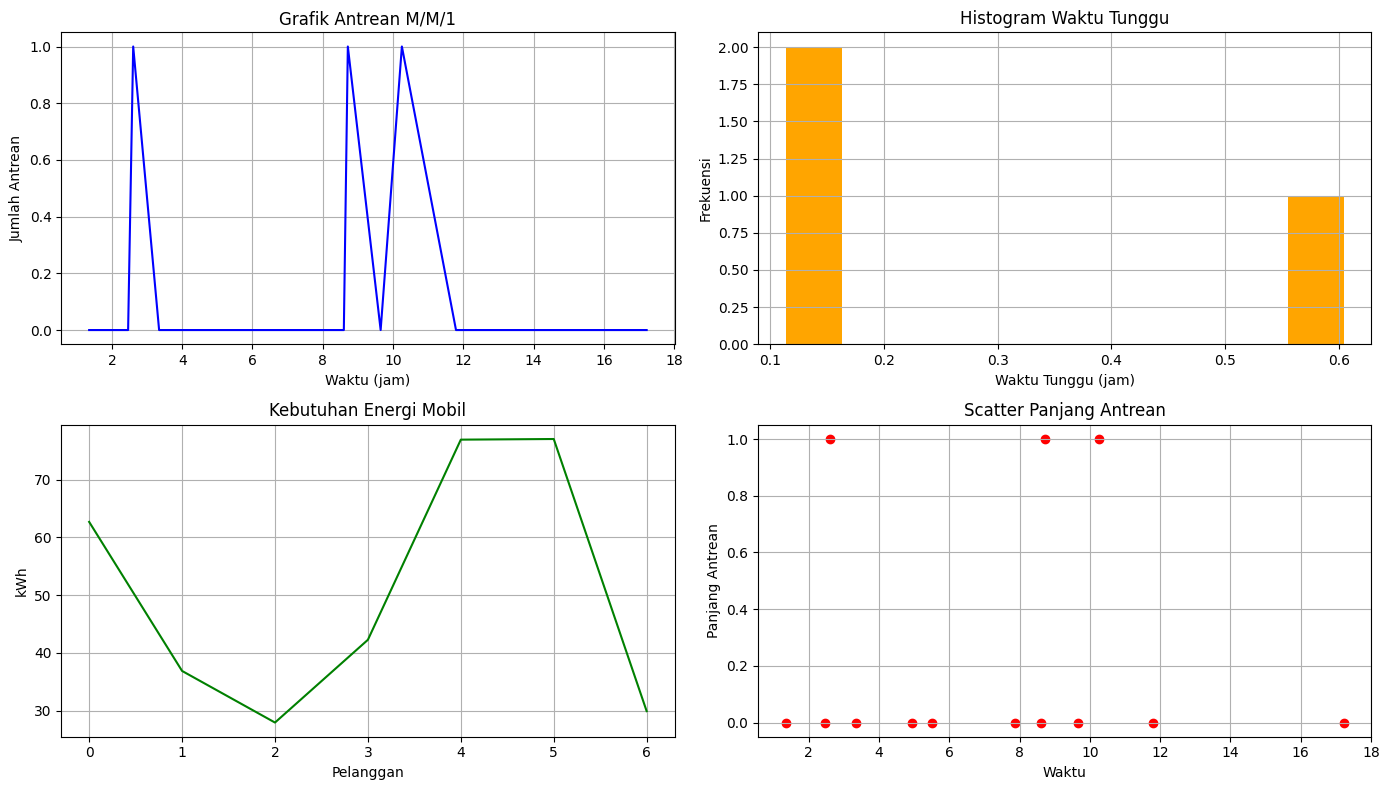


SIMULASI SPKLU M/M/2

Pelanggan 1 datang pada 0.05 jam (3.01 menit)
Kebutuhan energi mobil : 29.59 kWh
Pelanggan dilayani Server 1
Lama charging : 0.59 jam (35.51 menit)
Pelanggan 1 selesai pada 0.64 jam (38.52 menit)

Pelanggan 2 datang pada 1.91 jam (114.84 menit)
Kebutuhan energi mobil : 78.91 kWh
Pelanggan dilayani Server 1
Lama charging : 1.58 jam (94.69 menit)

Pelanggan 3 datang pada 2.21 jam (132.31 menit)
Kebutuhan energi mobil : 64.07 kWh
Pelanggan dilayani Server 2
Lama charging : 1.28 jam (76.89 menit)

Pelanggan 4 datang pada 2.26 jam (135.35 menit)
Kebutuhan energi mobil : 75.33 kWh
Pelanggan 4 masuk antrean
Pelanggan 3 selesai pada 3.49 jam (209.19 menit)
Pelanggan 4 menunggu 1.23 jam (73.84 menit)
Pelanggan 2 selesai pada 3.49 jam (209.53 menit)

Pelanggan 5 datang pada 4.33 jam (259.70 menit)
Kebutuhan energi mobil : 44.72 kWh
Pelanggan dilayani Server 1
Lama charging : 0.89 jam (53.66 menit)
Pelanggan 4 selesai pada 4.99 jam (299.59 menit)
Pelanggan 5 selesai pada 5.

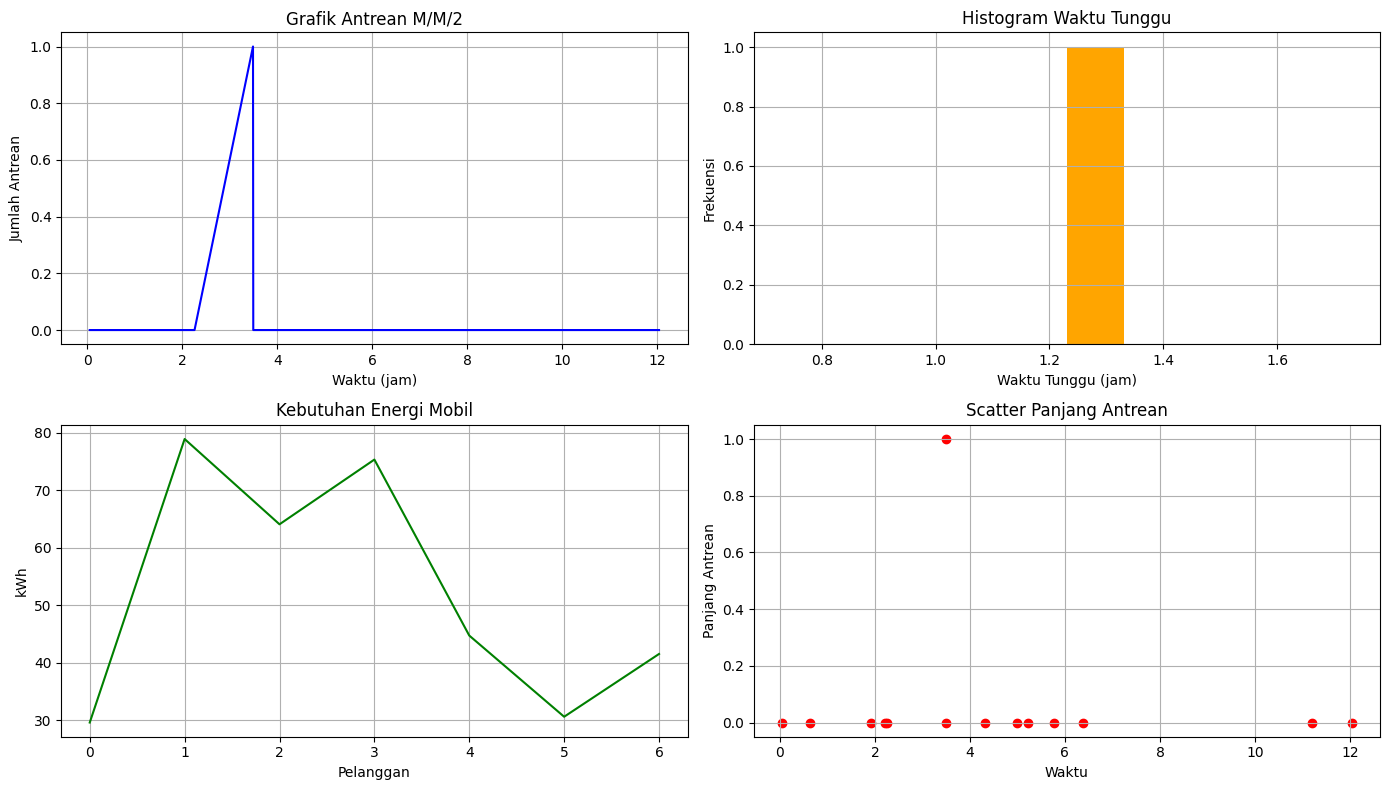

In [6]:
# =========================================================
# SIMULASI ANTRIAN M/M/1 DAN M/M/2 SPKLU
# DENGAN JAM KERJA, kWh MOBIL, DAN VISUALISASI
# =========================================================

import random
from collections import deque
import matplotlib.pyplot as plt

# =========================================================
# CLASS EVENT
# =========================================================

class Event:

    def __init__(self, waktu, tipe, pelanggan):

        self.waktu = waktu
        self.tipe = tipe
        self.pelanggan = pelanggan

# =========================================================
# CLASS SISTEM ANTRIAN
# =========================================================

class QueueingSystem:

    def __init__(
        self,
        num_servers,
        arrival_rate,
        charger_power,
        working_hours):

        # jumlah server
        self.num_servers = num_servers

        # lambda kedatangan
        self.arrival_rate = arrival_rate

        # daya charger (kW)
        self.charger_power = charger_power

        # jam kerja
        self.working_hours = working_hours

        # antrean
        self.queue = deque()

        # daftar event
        self.event_list = []

        # status server
        self.servers_busy = [False] * num_servers

        # waktu sekarang
        self.current_time = 0

        # statistik
        self.total_customers = 0
        self.customers_served = 0

        self.total_wait_time = 0
        self.total_service_time = 0

        # data visualisasi
        self.queue_history = []
        self.time_history = []
        self.waiting_history = []

        # data kWh kendaraan
        self.kwh_history = []

    # =====================================================
    # GENERATE WAKTU KEDATANGAN
    # =====================================================

    def generate_arrival(self):
        return random.expovariate(self.arrival_rate)

    # =====================================================
    # GENERATE KWH MOBIL
    # =====================================================

    def generate_kwh(self):

        # mobil membutuhkan charging
        # antara 20 - 80 kWh

        return random.uniform(20, 80)

    # =====================================================
    # HITUNG WAKTU PELAYANAN
    # =====================================================

    def generate_service_time(self, kwh):

        # waktu charging = energi / daya

        return kwh / self.charger_power

    # =====================================================
    # TAMBAH EVENT
    # =====================================================

    def add_event(self, event):

        self.event_list.append(event)

        self.event_list.sort(
            key=lambda x: x.waktu)

    # =====================================================
    # RUN SIMULATION
    # =====================================================

    def run_simulation(self, max_customers):

        self.total_customers = 1

        # pelanggan pertama
        first_arrival = self.generate_arrival()

        self.add_event(
            Event(first_arrival, "arrival", 1))

        # simulasi berjalan
        while (
            self.customers_served < max_customers
            and self.current_time < self.working_hours ):

            current_event = self.event_list.pop(0)
            self.current_time = current_event.waktu

            # simpan data grafik
            self.queue_history.append(len(self.queue))
            self.time_history.append(self.current_time)

            # proses event
            if current_event.tipe == "arrival":
                self.handle_arrival(
                    current_event,
                    max_customers )

            elif current_event.tipe == "departure":
                self.handle_departure(
                    current_event)


        print("\n===================================")
        print("SIMULASI BERAKHIR")
        print("===================================")
        print(f"Waktu operasional selesai : "f"{self.current_time:.2f} jam" )
        print(f"Total pelanggan dilayani : "f"{self.customers_served}")

    # =====================================================
    # HANDLE ARRIVAL
    # =====================================================

    def handle_arrival(
        self,
        event,
        max_customers ):

        menit_datang = event.waktu * 60

        print(
            f"\nPelanggan {event.pelanggan} datang "
            f"pada {event.waktu:.2f} jam "
            f"({menit_datang:.2f} menit)")

        # generate kebutuhan charging
        kwh = self.generate_kwh()
        self.kwh_history.append(kwh)

        print(
            f"Kebutuhan energi mobil : "
            f"{kwh:.2f} kWh")

        # pelanggan berikutnya
        if self.total_customers < max_customers:
            self.total_customers += 1
            next_arrival = (
                self.current_time +
                self.generate_arrival())
            self.add_event(
                Event(
                    next_arrival,
                    "arrival",
                    self.total_customers))

        # cek server kosong
        free_server = -1
        for i in range(self.num_servers):
            if not self.servers_busy[i]:
                free_server = i
                break
        # jika ada server kosong
        if free_server != -1:
            self.servers_busy[free_server] = True
            # hitung lama charging
            service_time = self.generate_service_time(kwh)
            self.total_service_time += service_time
            selesai = (
                self.current_time +
                service_time )
            self.add_event(
                Event(
                    selesai,
                    "departure",
                    event.pelanggan) )
            print(f"Pelanggan dilayani"f"Server {free_server+1}")
            print(f"Lama charging : "f"{service_time:.2f} jam "
                f"({service_time*60:.2f} menit)")

        else:

            # masuk antrean
            self.queue.append({
                "id": event.pelanggan,
                "arrival_time": self.current_time,
                "kwh": kwh})
            print(f"Pelanggan {event.pelanggan} "f"masuk antrean")

    # =====================================================
    # HANDLE DEPARTURE
    # =====================================================

    def handle_departure(self, event):
        menit_selesai = event.waktu * 60
        print(
            f"Pelanggan {event.pelanggan} selesai "
            f"pada {event.waktu:.2f} jam "
            f"({menit_selesai:.2f} menit)")
        self.customers_served += 1
        # jika antrean kosong
        if len(self.queue) == 0:
            for i in range(self.num_servers):
                self.servers_busy[i] = False
        else:
            next_customer = self.queue.popleft()
            waiting_time = (
                self.current_time -
                next_customer["arrival_time"])
            self.total_wait_time += waiting_time
            self.waiting_history.append(
                waiting_time)
            print(
                f"Pelanggan "
                f"{next_customer['id']} "
                f"menunggu "
                f"{waiting_time:.2f} jam "
                f"({waiting_time*60:.2f} menit)")

            # waktu charging berdasarkan kWh
            service_time = self.generate_service_time(
                next_customer["kwh"])
            self.total_service_time += service_time
            selesai = (self.current_time + service_time )
            self.add_event(Event(selesai,"departure",next_customer["id"]))

    # =====================================================
    # HASIL SIMULASI
    # =====================================================

    def get_results(self):

        # rata-rata waktu tunggu
        average_wait = (self.total_wait_time / self.customers_served)

        # rata-rata charging
        average_service = (self.total_service_time / self.customers_served )

        # rata-rata kWh
        average_kwh = (sum(self.kwh_history) /len(self.kwh_history))




        # utilisasi server
        rho = (self.arrival_rate *average_service) / self.num_servers

        return {
            "Jumlah Server":self.num_servers,
            "Lambda":self.arrival_rate,
            "Daya Charger (kW)":self.charger_power,
            "Jam Kerja":self.working_hours,
            "Total Pelanggan":self.customers_served,
            "Rata-rata kWh Mobil":average_kwh,
            "Rata-rata Waktu Charging (jam)":average_service,
            "Rata-rata Waktu Charging (menit)":average_service * 60,
            "Rata-rata Waktu Tunggu (jam)":average_wait,
            "Rata-rata Waktu Tunggu (menit)":average_wait * 60,
            "Utilisasi Server":rho}

    # =====================================================
    # VISUALISASI
    # =====================================================

    def visualisasi(self):
        plt.figure(figsize=(14,8))

        # ---------------------------------------------
        # Grafik antrean
        # ---------------------------------------------
        plt.subplot(2,2,1)
        plt.plot(
            self.time_history,
            self.queue_history,
            color='blue')
        plt.title(f"Grafik Antrean M/M/{self.num_servers}" )
        plt.xlabel("Waktu (jam)")
        plt.ylabel("Jumlah Antrean")
        plt.grid(True)

        # ---------------------------------------------
        # Histogram waktu tunggu
        # ---------------------------------------------
        plt.subplot(2,2,2)
        plt.hist(
            self.waiting_history,
            bins=10,
            color='orange')
        plt.title("Histogram Waktu Tunggu")
        plt.xlabel("Waktu Tunggu (jam)")
        plt.ylabel("Frekuensi")
        plt.grid(True)

        # ---------------------------------------------
        # Grafik kebutuhan energi
        # ---------------------------------------------
        plt.subplot(2,2,3)
        plt.plot(
            self.kwh_history,
            color='green')
        plt.title("Kebutuhan Energi Mobil")
        plt.xlabel("Pelanggan")
        plt.ylabel("kWh")
        plt.grid(True)

        # ---------------------------------------------
        # Scatter antrean
        # ---------------------------------------------
        plt.subplot(2,2,4)
        plt.scatter(
            self.time_history,
            self.queue_history,
            color='red' )
        plt.title("Scatter Panjang Antrean")
        plt.xlabel("Waktu")
        plt.ylabel("Panjang Antrean")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# =========================================================
# PARAMETER SISTEM
# =========================================================

ARRIVAL_RATE = 0.5
CHARGER_POWER = 50
MAX_CUSTOMERS = 30
WORKING_HOURS = 12

# =========================================================
# SIMULASI M/M/1
# =========================================================

print("\n===================================")
print("SIMULASI SPKLU M/M/1")
print("===================================")

system_one = QueueingSystem(
    num_servers = 1,
    arrival_rate = ARRIVAL_RATE,
    charger_power = CHARGER_POWER,
    working_hours = WORKING_HOURS)

system_one.run_simulation(MAX_CUSTOMERS)
results_one = system_one.get_results()

print("\n--- HASIL M/M/1 ---")
for key, value in results_one.items():
    print(f"{key}: {value:.4f}")
system_one.visualisasi()

# =========================================================
# SIMULASI M/M/2
# =========================================================

print("\n===================================")
print("SIMULASI SPKLU M/M/2")
print("===================================")

system_two = QueueingSystem(
    num_servers = 2,
    arrival_rate = ARRIVAL_RATE,
    charger_power = CHARGER_POWER,
    working_hours = WORKING_HOURS)
system_two.run_simulation(MAX_CUSTOMERS)
results_two = system_two.get_results()

print("\n--- HASIL M/M/2 ---")
for key, value in results_two.items():
    print(f"{key}: {value:.4f}")
system_two.visualisasi()